In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing data and normalizing columns  (`trash_haulers`)

In [3]:
trash_haulers = pd.read_csv('../data/trash_hauler_report.csv')
trash_haulers.head()

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011


In [4]:
trash_haulers

,Request Number,Date Opened,Request,Description,Incident Address,Zip Code,Trash Hauler,Trash Route,Council District,State Plan X,State Plan Y
0,25270,11/1/2017,Trash - Backdoor,"house with the wheel chair ramp, they share dr...",3817 Crouch Dr,37207.0,RED RIVER,3205,2.0,1727970.412,686779.4781
1,25274,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/Trash miss Tuesday.,4028 Clarksville Pike,37218.0,RED RIVER,4202,1.0,1721259.366,685444.7996
2,25276,11/1/2017,Trash - Curbside/Alley Missed Pickup,Curb/trash miss Tuesday.,6528 Thunderbird Dr,37209.0,RED RIVER,4205,20.0,1707026.753,659887.4716
3,25307,11/1/2017,Trash - Curbside/Alley Missed Pickup,missed,2603 old matthews rd,37207.0,WASTE IND,2206,2.0,1735691.771,685027.2459
4,25312,11/1/2017,Trash - Curbside/Alley Missed Pickup,Missed the even side of the road.,604 croley dr,37209.0,RED RIVER,4203,20.0,1710185.772,664205.1011
...,...,...,...,...,...,...,...,...,...,...,...
20221,267125,11/1/2019,Trash - Curbside/Alley Missed Pickup,MISSED...NEIGHBORS MISSED,2731 Murfreesboro Pike,37013.0,RED RIVER,4502,32.0,1781137.263,632448.5511
20222,267126,11/1/2019,Trash - Curbside/Alley Missed Pickup,entire alley,"1621 Long Ave, Nashville, TN 37206, United States",37206.0,METRO,9508,6.0,1749711.399,669201.6016
20223,267130,11/1/2019,Trash - Curbside/Alley Missed Pickup,missed several,"2943 Windemere Cir, Nashville, TN 37214, Unite...",37214.0,RED RIVER,1502,15.0,1770293.388,674936.3038
20224,267134,11/1/2019,Trash - Curbside/Alley Missed Pickup,Caller stated trash was missed & were only pic...,"3325 Murfreesboro Pike, Nashville, TN 37013, U...",37013.0,RED RIVER,4502,32.0,1785224.998,627146.4002


In [5]:
trash_haulers = trash_haulers.rename(columns={'Request ': 'Request'})

In [6]:
trash_haulers['Zip Code'] = trash_haulers['Zip Code'].astype('Int64').astype(str)

In [7]:
trash_haulers['Trash Hauler'] = trash_haulers['Trash Hauler'].str.upper()

#### Normalizing street names

In [8]:
trash_haulers['incident_street'] = trash_haulers['Incident Address'].str.split(',', expand = True)[0].str.upper()

In [9]:
trash_haulers['incident_street'] = trash_haulers['incident_street'].str.replace('\bROAD$', 'RD', regex=True)

In [10]:
trash_haulers['incident_street'] = trash_haulers['incident_street'].str.replace('\bCOURT$', 'CT', regex=True)

In [11]:
trash_haulers['incident_street'] = trash_haulers['incident_street'].str.replace('\bDRIVE$', 'DR', regex=True)

#### Making Unique Street Identifier

In [12]:
trash_haulers['street_id'] = trash_haulers['incident_street'] + ' ' + trash_haulers['Zip Code']

### Subsetting missed pickups (`missed_pickups`)

In [13]:
missed_req = trash_haulers['Request'].value_counts().index[0]

In [14]:
missed_pickups = (trash_haulers.loc[
    (trash_haulers['Request'] == missed_req) | 
    (trash_haulers['Description'].str.contains('miss|skip|not pick|fail|not been pick|did not|was not|forgot', case=False, na=False))]).copy()

In [15]:
missed_pickups['Date Opened'] = pd.to_datetime(missed_pickups['Date Opened'])

In [16]:
missed_pickups['Year'] = missed_pickups['Date Opened'].dt.year

In [17]:
missed_pickups['Summer'] = missed_pickups['Date Opened'].dt.month.isin([6, 7 , 8])

In [18]:
missed_pickups.groupby('Trash Hauler')['Request Number'].count()

Trash Hauler
METRO         3100
RED RIVER    13099
WASTE IND     1163
Name: Request Number, dtype: int64

### Subsetting Red River missed pickups (`red_missed`)

In [19]:
red_missed = missed_pickups.loc[missed_pickups['Trash Hauler'] == 'RED RIVER']

In [20]:
red_missed.street_id.value_counts().head(60)

street_id
12546 OLD HICKORY BLVD 37013      21
5135 HICKORY HOLLOW PKWY 37013    20
6007 OBRIEN AVE 37209             19
3710 N NATCHEZ CT 37211           19
1584 BELL RD 37211                18
802 CRESCENT RD 37205             17
320 OLD HICKORY BLVD 37221        17
607 ESTES RD 37215                16
1537 HARDING PL 37215             15
1601 S OBSERVATORY DR 37215       14
162 ANTIOCH PIKE 37211            14
617 KINSEY BLVD 37115             14
116 MARGARET ST 37115             14
3929 STEWARTS LN 37218            14
14881 OLD HICKORY BLVD 37013      13
6301 HARDING PIKE 37205           12
2731 MURFREESBORO PIKE 37013      12
111 BARTON LN 37214               11
209 PAGE RD 37205                 11
204 CLEARBROOK CT 37205           11
4024 STEWARTS LN 37218            10
2774 SMITH SPRINGS RD 37217       10
1916 S HAMILTON RD 37218          10
502 GEORGETOWN DR 37205           10
115 BARTON LN 37214               10
1701 CEDAR GROVE RD 37218         10
208 FLINT RIDGE CT 37189    

In [21]:
fined_pickups = red_missed.street_id.value_counts().to_frame()

In [22]:
fined_pickups['count'] = fined_pickups['count'] - 1

In [23]:
red_fines = fined_pickups['count'].sum() * 200
red_fines

np.int64(945400)

### Subsetting Metro Pickups (`metro_missed`)

In [24]:
metro_missed = missed_pickups.loc[missed_pickups['Trash Hauler'] == 'METRO']

In [25]:
metro_fines = (metro_missed.street_id.value_counts().to_frame()['count'] - 1).sum() * 200
metro_fines

np.int64(222600)

### Subsetting WASTE IND (`waste_missed`)

In [26]:
waste_missed = missed_pickups.loc[missed_pickups['Trash Hauler'] == 'WASTE IND']

In [27]:
waste_fines = (waste_missed.street_id.value_counts().to_frame()['count'] - 1).sum() * 200
waste_fines

np.int64(79400)

### Total Missed Pickups by Route

In [28]:
missed_pickups['Trash Route'].value_counts()

Trash Route
4504     338
3302     297
4404     263
1303     258
9303     252
        ... 
4201S      3
2405S      3
3303S      2
2505S      2
1502S      1
Name: count, Length: 172, dtype: int64

### Visualizations

In [29]:
import matplotlib.dates as mdates

In [30]:
date_count = missed_pickups.groupby('Trash Hauler')['Date Opened'].value_counts().to_frame().reset_index()

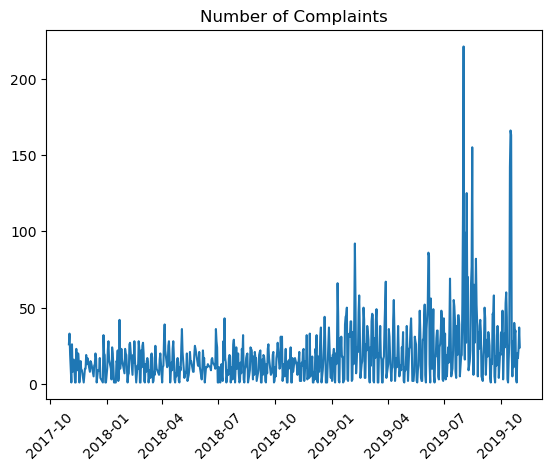

In [31]:
ax = sns.lineplot(data = date_count[date_count['Trash Hauler'] == 'RED RIVER'], x='Date Opened', y='count')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.set(title='Number of Complaints', xlabel='', ylabel='')
plt.xticks(rotation = 45)
plt.show()

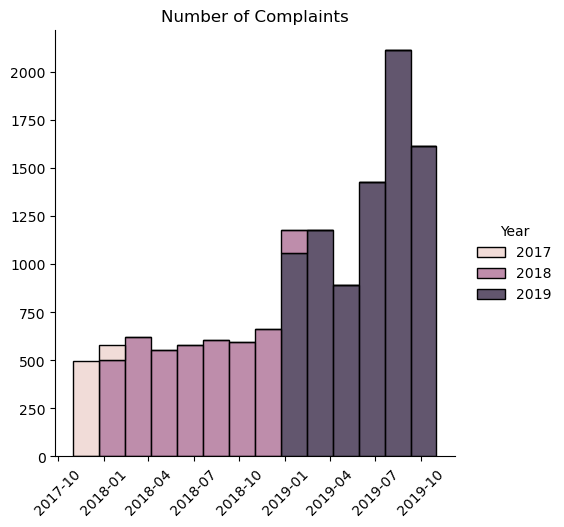

In [32]:
ax = sns.displot(data=red_missed,
        x='Date Opened',
        bins = 14, 
        kde=False,
        hue='Year',
        multiple='stack')
ax.set(title='Number of Complaints', xlabel='', ylabel='')
plt.xticks(rotation = 45)
plt.show()

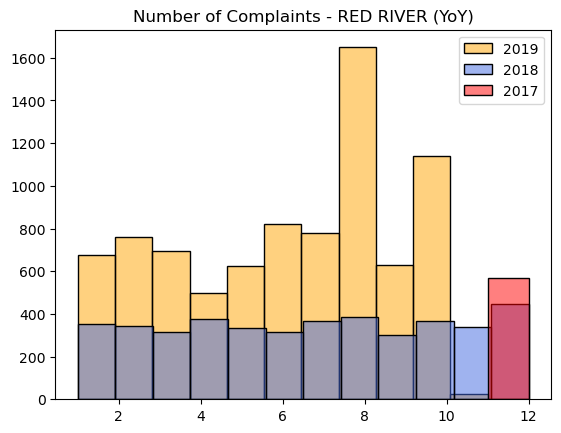

In [33]:
red_missed_17 = red_missed[red_missed['Year'] == 2017].copy()
red_missed_18 = red_missed[red_missed['Year'] == 2018].copy()
red_missed_19 = red_missed[red_missed['Year'] == 2019].copy()

red_missed_17['Month'] = red_missed_17['Date Opened'].dt.month
red_missed_18['Month'] = red_missed_18['Date Opened'].dt.month
red_missed_19['Month'] = red_missed_19['Date Opened'].dt.month

sns.histplot(
    data=red_missed_19,
    x='Month',
    bins=11,
    kde=False,
    color='orange',
    label='2019',
    alpha=0.5
)
sns.histplot(
    data=red_missed_18,
    x='Month',
    bins=12,
    kde=False,
    color='royalblue',
    label='2018',
    alpha=0.5
)
ax = sns.histplot(
    data=red_missed_17,
    x='Month',
    bins=1,
    kde=False,
    color='red',
    label='2017',
    alpha=0.5
)

ax.set(title='Number of Complaints - RED RIVER (YoY)', xlabel='', ylabel='')
plt.legend()
plt.show()

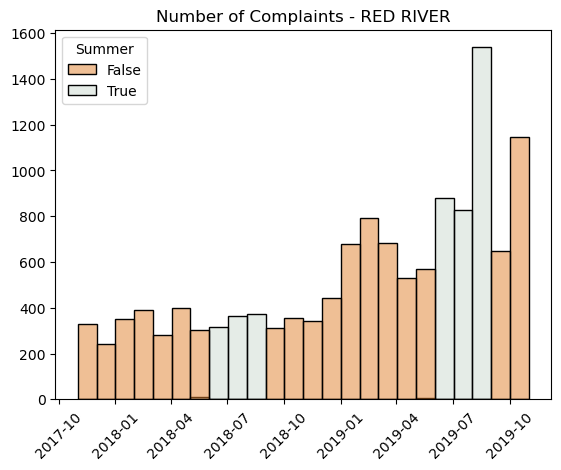

In [42]:
ax = sns.histplot(data=red_missed,
        x='Date Opened',
        bins = 24, 
        kde=False,
        hue='Summer',
        palette=['#E1812C','#ccdad1'])
ax.set(title='Number of Complaints - RED RIVER', xlabel='', ylabel='')
plt.xticks(rotation = 45)
plt.show()

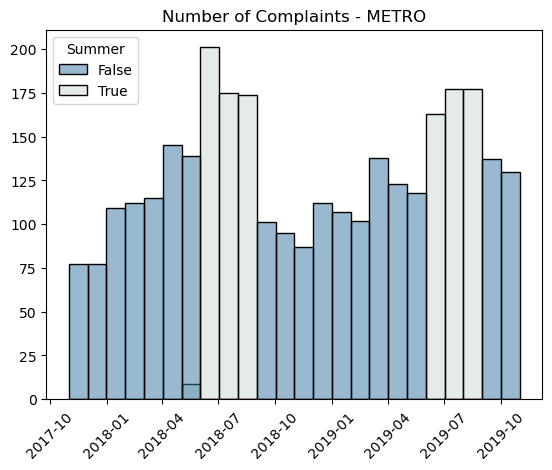

In [38]:
ax = sns.histplot(data=metro_missed,
        x='Date Opened',
        bins = 24, 
        kde=False,
        hue='Summer',
        palette=['#3274A1','#ccdad1'])
ax.set(title='Number of Complaints - METRO', xlabel = '', ylabel='')
plt.xticks(rotation = 45)
plt.show()

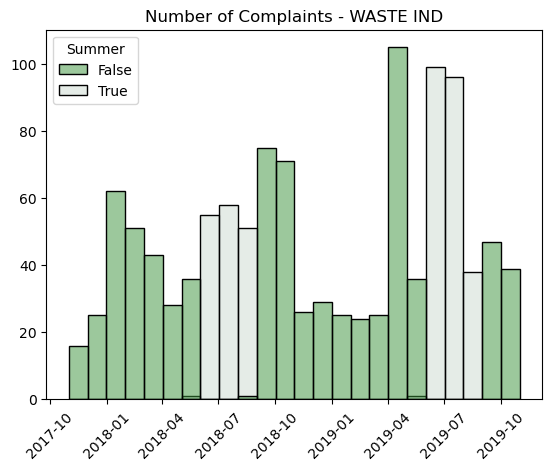

In [39]:
ax = sns.histplot(data=waste_missed,
        x='Date Opened',
        bins = 24, 
        kde=False,
        hue='Summer',
        palette=['#3A923A','#ccdad1'])
ax.set(title='Number of Complaints - WASTE IND', xlabel = '', ylabel='')
plt.xticks(rotation = 45)
plt.show()